In [1]:
import numpy as np
import matplotlib.pyplot as plt

from resource_model import ResourceModel
from const import (COPPER_AVERAGE_REGIONS_TO_IMAGE, CLASS_TO_REGION_DICT, 
                   REGION_TO_CLASS_DICT, path_input_data)

In [2]:
copper_regions = {
    'copper_regions': ['Other North America countries',
                    'USA',
                    'South America',
                    'Europe',
                    'Rest of Asia',
                    'Africa',
                    'Oceania',
                    'India',
                    'Japan',
                    'Korea'],
    'china': ['China']}

""" copper_regions ={
    'North America': ['Other North America countries'],
    'US Europe' : ['USA', 'Europe'],
    'Africa' : ['Africa'], 
    'south america' :  ['South America'],
    'rest of asia' : ['Rest of Asia'],
    'Oceania' : ['Oceania'],
    'India' : ['India'],
    'Japan' : ['Japan'],
    'Korea' : ['Korea'],
    'China': ['China']
    } """

" copper_regions ={\n    'North America': ['Other North America countries'],\n    'US Europe' : ['USA', 'Europe'],\n    'Africa' : ['Africa'], \n    'south america' :  ['South America'],\n    'rest of asia' : ['Rest of Asia'],\n    'Oceania' : ['Oceania'],\n    'India' : ['India'],\n    'Japan' : ['Japan'],\n    'Korea' : ['Korea'],\n    'China': ['China']\n    } "

In [3]:
# COPPER
copper = ResourceModel(resource_group = 'metals', resource = 'copper', 
                       image_mat_available = True, start_year = 2012)

copper.data_grouped_regions(regions_grouping = copper_regions) #list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()


In [4]:
copper.historic_consumption_data

,USA,China,Europe,Other North America countries,South America,Africa,Oceania,India,Japan,Korea,Rest of Asia
2012,1760000,8153324.5,3918298.0,304800,939002.5,344962.5,132922.6843,687541,996028,733303,1887521.0
2013,1760000,9033770.5,3862498.0,529900,1037588.0,333500.5,132360.0122,736278,1005128,737512,1740808.0
2014,1780000,10093567.0,4240343.0,313700,893342.0,309498.0,146715.1731,817217,1043399,687059,1682321.5
2015,1840000,10219904.0,4159392.0,498100,783441.5,328572.0,145309.2204,874160,1018535,673976,1728791.5
2016,1880000,10587051.5,3652886.5,667000,1007907.5,307803.5,129100.4246,909388,987437,704084,1927030.5
2017,1860000,10973103.0,3575801.5,672000,1098765.0,302460.5,127823.2195,974269,1018314,714413,1915413.0


In [5]:
# TODO: define groups for grouping of fitting of copper consumption
copper.sum_IMAGE_drivers_regions(COPPER_AVERAGE_REGIONS_TO_IMAGE)
copper.match_MAT_data_to_regions_year(match_external_regions=True)
copper.calculate_historic_other_fraction()

In [6]:
# test if there are negative values in other fraction 
copper.historic_other_fraction_consumption

,Africa,China,Europe,India,Japan,Korea,Oceania,Other North America countries,Rest of Asia,South America,USA
2012,-26084.331474,6.802981e+06,2.261163e+06,328120.983785,801373.547460,668455.510669,37175.555109,19141.547029,1.042737e+06,463674.442698,806973.604454
2013,-173828.206066,7.576939e+06,2.086888e+06,337519.442954,785555.328818,661436.402751,19155.493038,215615.934010,8.224952e+05,525737.162475,780882.114683
2014,-4421.999531,8.473371e+06,2.107213e+06,359654.862944,768317.522090,595977.656717,22706.949387,-52525.497531,7.085295e+05,309475.069121,689669.203527
2015,-86595.727588,8.322112e+06,1.672890e+06,347208.614979,645969.776674,561227.774215,-14178.957406,44802.218191,6.374004e+05,189908.704953,492594.871262
2016,-100372.331926,8.687888e+06,1.639632e+06,391147.132119,759685.683007,618228.911645,21482.982929,275700.430092,8.756671e+05,527818.051238,772932.159720
2017,-169901.908698,8.888019e+06,1.605835e+06,435313.657526,736306.521309,627348.602250,11919.901086,250230.328025,7.740472e+05,477061.056117,794647.399072


In [7]:
copper.image_mat_material_regions

,Other North America countries,USA,South America,Europe,Rest of Asia,China,Africa,Oceania,India,Japan,Korea
2012,285658.452971,9.530264e+05,475328.057302,1.657135e+06,8.447840e+05,1.350344e+06,371046.831474,95747.129191,359420.016215,194654.452540,64847.489331
2013,314284.065990,9.791179e+05,511850.837525,1.775610e+06,9.183128e+05,1.456831e+06,507328.706066,113204.519162,398758.557046,219572.671182,76075.597249
2014,366225.497531,1.090331e+06,583866.930879,2.133130e+06,9.737920e+05,1.620196e+06,313919.999531,124008.223713,457562.137056,275081.477910,91081.343283
2015,453297.781809,1.347405e+06,593532.795047,2.486502e+06,1.091391e+06,1.897792e+06,415167.727588,159488.177806,526951.385021,372565.223326,112748.225785
2016,391299.569908,1.107068e+06,480089.448762,2.013254e+06,1.051363e+06,1.899164e+06,408175.831926,107617.441671,518240.867881,227751.316993,85855.088355
2017,421769.671975,1.065353e+06,621703.943883,1.969967e+06,1.141366e+06,2.085084e+06,472362.408698,115903.318414,538955.342474,282007.478691,87064.397750


In [8]:
# deal with single negative numbers in historic other fraction by replacing with np.nan
copper.historic_other_fraction_consumption[copper.historic_other_fraction_consumption < 0] = np.nan
copper.historic_other_fraction_consumption


,Africa,China,Europe,India,Japan,Korea,Oceania,Other North America countries,Rest of Asia,South America,USA
2012,NaN,6.802981e+06,2.261163e+06,328120.983785,801373.547460,668455.510669,37175.555109,19141.547029,1.042737e+06,463674.442698,806973.604454
2013,NaN,7.576939e+06,2.086888e+06,337519.442954,785555.328818,661436.402751,19155.493038,215615.934010,8.224952e+05,525737.162475,780882.114683
2014,NaN,8.473371e+06,2.107213e+06,359654.862944,768317.522090,595977.656717,22706.949387,NaN,7.085295e+05,309475.069121,689669.203527
2015,NaN,8.322112e+06,1.672890e+06,347208.614979,645969.776674,561227.774215,NaN,44802.218191,6.374004e+05,189908.704953,492594.871262
2016,NaN,8.687888e+06,1.639632e+06,391147.132119,759685.683007,618228.911645,21482.982929,275700.430092,8.756671e+05,527818.051238,772932.159720
2017,NaN,8.888019e+06,1.605835e+06,435313.657526,736306.521309,627348.602250,11919.901086,250230.328025,7.740472e+05,477061.056117,794647.399072


In [9]:
# deal with negative numbers for Africa by assuming IMAGE Mat values are right + adding a fraction on top that is similar to the other countries

share_mat_data = copper.image_mat_material_regions/copper.historic_consumption_data
mean = share_mat_data.loc[:, "China" : "USA"].mean().mean() # MAT data is roughly 50% of total consumption in other regions --> assume same for African regions
#TODO or better on per capita level than on total region level?

africa_copper_mat = copper.image_mat_material_regions["Africa"]

tota_africa_new = africa_copper_mat/(mean*100)*100

# 1- mean is part of total copper consumption that is not covered by MAT
share_to_project_africa = tota_africa_new*(1-mean)

# replace nan values for Africa
copper.historic_other_fraction_consumption["Africa"] = share_to_project_africa
copper.historic_other_fraction_consumption


,Africa,China,Europe,India,Japan,Korea,Oceania,Other North America countries,Rest of Asia,South America,USA
2012,365426.369220,6.802981e+06,2.261163e+06,328120.983785,801373.547460,668455.510669,37175.555109,19141.547029,1.042737e+06,463674.442698,806973.604454
2013,499643.902960,7.576939e+06,2.086888e+06,337519.442954,785555.328818,661436.402751,19155.493038,215615.934010,8.224952e+05,525737.162475,780882.114683
2014,309164.870640,8.473371e+06,2.107213e+06,359654.862944,768317.522090,595977.656717,22706.949387,NaN,7.085295e+05,309475.069121,689669.203527
2015,408878.940447,8.322112e+06,1.672890e+06,347208.614979,645969.776674,561227.774215,NaN,44802.218191,6.374004e+05,189908.704953,492594.871262
2016,401992.955098,8.687888e+06,1.639632e+06,391147.132119,759685.683007,618228.911645,21482.982929,275700.430092,8.756671e+05,527818.051238,772932.159720
2017,465207.260443,8.888019e+06,1.605835e+06,435313.657526,736306.521309,627348.602250,11919.901086,250230.328025,7.740472e+05,477061.056117,794647.399072


In [10]:
# Fit models 
copper.calculate_regressors(copper.historic_other_fraction_consumption)
copper.fit_models()

copper_regions
Optimal parameters not found: Number of calls to function has reached maxfev = 800.
china


c:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:287: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.exp(-c * X))
c:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:303: RuntimeWarning: overflow encountered in exp
  return c / (1+ a * np.exp(-b * X))
c:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:287: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.exp(-c * X))
c:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:132: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
c:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:132: OptimizeWarning: Covariance of the parameters could not be estimated

In [11]:
# Best models

copper.best_rmse_models
copper.merged_rmse_r2

copper_regions                   china          
                                   RMSE       R^2          RMSE       R^2
Model                                                                    
log-log model                  0.000008  0.107201  4.089953e-08  0.822092
semi-log model                 0.000007  0.010527  3.585564e-08  0.836466
log-inverse model              0.000008  0.154806  3.444862e-08  0.851690
log-log-inverse model          0.000007  0.159249  1.339724e-08  0.946872
log-log-square model           0.000008  0.151745  1.404191e-08  0.944247
non-linear inverse model       0.000007       NaN  3.396403e-08       NaN
gompertz model                 0.000006       NaN  3.266351e-05       NaN
logistic growth model               NaN       NaN  3.266351e-05       NaN
limited growth model           0.000006       NaN  1.031953e-08       NaN

In [12]:
copper.project_on_total(list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()), REGION_TO_CLASS_DICT)

In [13]:
copper.projection_per_region

,Other North America countries,USA,South America,Europe,Rest of Asia,China,Africa,Oceania,India,Japan,Korea
2017,0.002488,0.002488,0.002487,0.002488,0.002488,0.006140,0.002488,0.002488,0.000458,0.002488,0.002488
2018,0.002488,0.002488,0.002487,0.002488,0.002488,0.006174,0.002488,0.002488,0.000572,0.002488,0.002488
2019,0.002488,0.002488,0.002487,0.002488,0.002488,0.006189,0.002488,0.002488,0.000702,0.002488,0.002488
2020,0.002488,0.002488,0.002487,0.002488,0.002488,0.006191,0.002488,0.002488,0.000436,0.002488,0.002488
2021,0.002488,0.002488,0.002487,0.002488,0.002488,0.006196,0.002488,0.002488,0.000670,0.002488,0.002488
...,...,...,...,...,...,...,...,...,...,...,...
2096,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488
2097,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488
2098,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488
2099,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488


<Axes: >

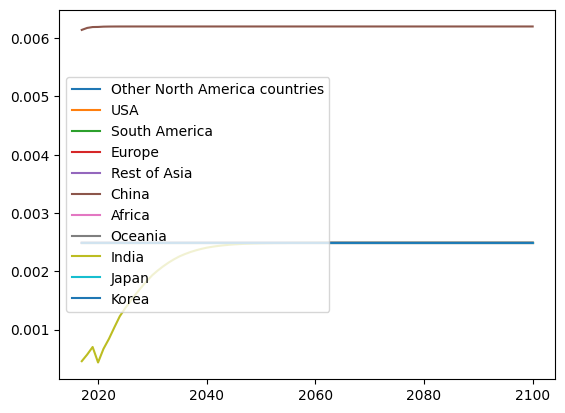

In [14]:

copper.projection_per_region.plot()

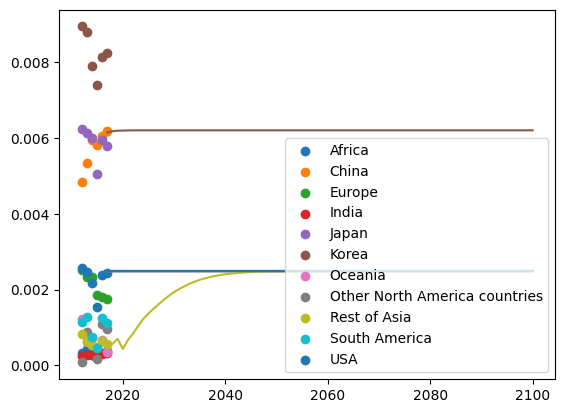

In [15]:
historic_fr_per_cap = copper.historic_other_fraction_consumption/copper.pop.loc[2012:]

fig, ax = plt.subplots()             # Create a figure containing a single Axes.

for region in copper.historic_other_fraction_consumption.columns:
    ax.scatter(list(copper.historic_other_fraction_consumption.index), historic_fr_per_cap[region], label = region)  # Plot some data on the Axes.

ax.plot(copper.projection_per_region)

ax.legend(loc = 'lower right')



plt.show()

In [16]:
copper.projection_per_region.loc[2017:]

,Other North America countries,USA,South America,Europe,Rest of Asia,China,Africa,Oceania,India,Japan,Korea
2017,0.002488,0.002488,0.002487,0.002488,0.002488,0.006140,0.002488,0.002488,0.000458,0.002488,0.002488
2018,0.002488,0.002488,0.002487,0.002488,0.002488,0.006174,0.002488,0.002488,0.000572,0.002488,0.002488
2019,0.002488,0.002488,0.002487,0.002488,0.002488,0.006189,0.002488,0.002488,0.000702,0.002488,0.002488
2020,0.002488,0.002488,0.002487,0.002488,0.002488,0.006191,0.002488,0.002488,0.000436,0.002488,0.002488
2021,0.002488,0.002488,0.002487,0.002488,0.002488,0.006196,0.002488,0.002488,0.000670,0.002488,0.002488
...,...,...,...,...,...,...,...,...,...,...,...
2096,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488
2097,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488
2098,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488
2099,0.002488,0.002488,0.002488,0.002488,0.002488,0.006199,0.002488,0.002488,0.002488,0.002488,0.002488


In [17]:
copper.image_mat_material_regions
copper.projection_per_region*copper.pop_100.loc[2017:]



,Other North America countries,USA,South America,Europe,Rest of Asia,China,Africa,Oceania,India,Japan,Korea
2017,639298.567558,8.086190e+05,1.053831e+06,2.263585e+06,3.368785e+06,8.830225e+06,3.101767e+06,80915.739745,6.142286e+05,317050.709520,189376.294574
2018,645593.835399,8.149873e+05,1.062961e+06,2.269485e+06,3.412601e+06,8.900259e+06,3.167324e+06,82040.339872,7.768083e+05,316398.377191,189743.931482
2019,651889.103240,8.213557e+05,1.072070e+06,2.275385e+06,3.456415e+06,8.942924e+06,3.232876e+06,83164.938967,9.633858e+05,315746.043835,190110.347374
2020,658184.371081,8.277240e+05,1.080946e+06,2.281285e+06,3.500222e+06,8.966489e+06,3.298396e+06,84289.520382,6.056193e+05,315093.672128,190473.821982
2021,663938.906155,8.341032e+05,1.089174e+06,2.286280e+06,3.541110e+06,8.982189e+06,3.365248e+06,85392.553268,9.410259e+05,314102.556634,190678.523187
...,...,...,...,...,...,...,...,...,...,...,...
2096,769548.614108,1.129265e+06,1.101851e+06,2.205338e+06,4.425133e+06,5.248240e+06,6.889008e+06,132477.137500,4.074574e+06,195925.975220,120192.072299
2097,767837.450991,1.129570e+06,1.096815e+06,2.198293e+06,4.413193e+06,5.195307e+06,6.900308e+06,132267.467012,4.053666e+06,194242.116061,119118.129732
2098,766126.287875,1.129875e+06,1.091778e+06,2.191248e+06,4.401253e+06,5.142375e+06,6.911608e+06,132057.796525,4.032758e+06,192558.256902,118044.187165
2099,764415.124758,1.130179e+06,1.086742e+06,2.184202e+06,4.389313e+06,5.089443e+06,6.922909e+06,131848.126037,4.011849e+06,190874.397743,116970.244598


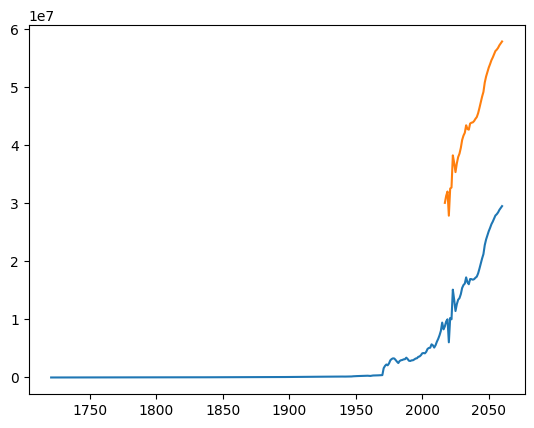

In [18]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.


ax.plot(copper.image_mat_data.sum(axis = 1))
ax.plot((copper.projection_per_region*copper.pop_100.loc[2017:]).sum(axis = 1) + copper.image_mat_data.sum(axis = 1))


plt.show()

In [ ]:
copper.project_on_total_IMAGE_regions(REGION_TO_CLASS_DICT, COPPER_AVERAGE_REGIONS_TO_IMAGE)


676

In [20]:
print(copper.projection_per_region_IMAGE)

      class_ 1  class_ 2  class_ 3  class_ 4  class_ 5  class_ 6  class_ 7  \
2017  0.002488  0.002488  0.002473  0.002322  0.002343  0.002295  0.001352   
2018  0.002488  0.002488  0.002476  0.002348  0.002368  0.002324  0.001467   
2019  0.002488  0.002488  0.002478  0.002371  0.002389  0.002350  0.001578   
2020  0.002488  0.002488  0.002462  0.002300  0.002334  0.002264  0.001421   
2021  0.002488  0.002488  0.002467  0.002327  0.002359  0.002297  0.001471   
...        ...       ...       ...       ...       ...       ...       ...   
2096  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488   
2097  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488   
2098  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488   
2099  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488   
2100  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488  0.002488   

      class_ 8  class_ 9  class_ 10  ...  class_ 17  class_ 18 

In [21]:
for region in REGION_TO_CLASS_DICT.values():
    for key, value in COPPER_AVERAGE_REGIONS_TO_IMAGE.items():
        if region in value:
            print(copper.region_model_match.get(key))

In [22]:
REGION_TO_CLASS_DICT
#

{'Canada': 'class_ 1',
 'USA': 'class_ 2',
 'Mexico': 'class_ 3',
 'Rest C. America': 'class_ 4',
 'Brazil': 'class_ 5',
 'Rest S. America': 'class_ 6',
 'N. Africa': 'class_ 7',
 'W. Africa': 'class_ 8',
 'E. Africa': 'class_ 9',
 'South Africa': 'class_ 10',
 'W. Europe': 'class_ 11',
 'C. Europe': 'class_ 12',
 'Turkey': 'class_ 13',
 'Ukraine region': 'class_ 14',
 'Kazakhstan region': 'class_ 15',
 'Russia': 'class_ 16',
 'Middle East': 'class_ 17',
 'India': 'class_ 18',
 'Korea': 'class_ 19',
 'China': 'class_ 20',
 'SE. Asia': 'class_ 21',
 'Indonesia': 'class_ 22',
 'Japan': 'class_ 23',
 'Oceania': 'class_ 24',
 'Rest S. Asia': 'class_ 25',
 'Rest S. Africa': 'class_ 26',
 'Global': 'class_ 27'}

In [23]:
copper.pop_original.columns

Index(['class_ 1', 'class_ 2', 'class_ 3', 'class_ 4', 'class_ 5', 'class_ 6',
       'class_ 7', 'class_ 8', 'class_ 9', 'class_ 10', 'class_ 11',
       'class_ 12', 'class_ 13', 'class_ 14', 'class_ 15', 'class_ 16',
       'class_ 17', 'class_ 18', 'class_ 19', 'class_ 20', 'class_ 21',
       'class_ 22', 'class_ 23', 'class_ 24', 'class_ 25', 'class_ 26'],
      dtype='object')